# Imports & Setup

In [ ]:
import os
import sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve
)

from torch.amp import autocast, GradScaler

# ---------------- CFG ----------------
SEED = 42
DATA_PATH = "../../datasets/url_feeds/processed/final_urls.csv"
OUT_DIR = "url_charcnn_stage3_model"

USE_SUBSAMPLE = True
SUBSAMPLE_N = 2_000_000    

MAX_LEN = 512
BATCH_SIZE = 256          # very large batch ok for pure CNN
NUM_EPOCHS = 3
EMBED_DIM = 160
NUM_FILTERS = 320
KERNEL_SIZES = (7,11,17,23)
DROPOUT = 0.3

LR = 3e-4
WEIGHT_DECAY = 0.01

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

DEVICE: cuda


# URL Normalization Helpers

In [2]:
try:
    from utils.helpers.url_filter import normalize_url
except:
    def normalize_url(u):
        if not isinstance(u, str): return ""
        u = u.strip().lower().replace("\\n", "").replace("\\r", "")
        u = re.sub(r"\s+", "", u)
        u = re.sub(r"^https?://", "", u)
        u = re.sub(r"^www\.", "", u)
        return u.rstrip("/")

# Load unified CSV and build URL subset

In [3]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Final URL dataset not found at: {DATA_PATH}")

print(f"\n[INFO] Loading Stage-3 dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, dtype={"url": str, "label": int})

print(f"[INFO] Raw rows loaded: {len(df):,}")
print("[INFO] Label distribution (raw):")
print(df["label"].value_counts())

# Ensure correct dtypes
df["url"] = df["url"].astype(str)
df["label"] = df["label"].astype(int)

# Optional subsample
if USE_SUBSAMPLE and len(df) > SUBSAMPLE_N:
    df = df.sample(n=SUBSAMPLE_N, random_state=SEED).reset_index(drop=True)
    print(f"[INFO] Subsampled dataset to {len(df):,} rows for training debug.")

# Normalize into urls_norm
df["urls_norm"] = df["url"].apply(normalize_url)
df = df[df["urls_norm"].str.len() > 0].reset_index(drop=True)

print(f"[INFO] Rows after dropping empty normalized URLs: {len(df):,}")
print("[INFO] Label distribution AFTER normalization:")
print(df["label"].value_counts())



[INFO] Loading Stage-3 dataset from: ../../datasets/url_feeds/processed/final_urls.csv
[INFO] Raw rows loaded: 11,026,377
[INFO] Label distribution (raw):
label
0    5522517
1    5503860
Name: count, dtype: int64
[INFO] Subsampled dataset to 2,000,000 rows for training debug.
[INFO] Rows after dropping empty normalized URLs: 2,000,000
[INFO] Label distribution AFTER normalization:
label
0    1001394
1     998606
Name: count, dtype: int64


# Train/Val split

In [4]:
train_df, val_df = train_test_split(
    df[["urls_norm", "label"]],
    test_size=0.05,               # 5% for validation
    random_state=SEED,
    stratify=df["label"],
)

print(f"\n[INFO] Train size: {len(train_df):,}")
print(f"[INFO] Val size:   {len(val_df):,}")
print("[INFO] Train label dist:")
print(train_df["label"].value_counts())
print("[INFO] Val label dist:")
print(val_df["label"].value_counts())


[INFO] Train size: 1,900,000
[INFO] Val size:   100,000
[INFO] Train label dist:
label
0    951324
1    948676
Name: count, dtype: int64
[INFO] Val label dist:
label
0    50070
1    49930
Name: count, dtype: int64


# Character vocabulary construction

In [ ]:
def build_char_vocab(series, extra_chars=None):
    chars = set()
    for text in series:
        for ch in text:
            chars.add(ch)

    if extra_chars:
        chars.update(extra_chars)

    # Reserve:
    # 0 -> PAD, 1 -> UNK
    sorted_chars = sorted(chars)
    char2idx = {"<PAD>": 0, "<UNK>": 1}
    idx2char = {0: "<PAD>", 1: "<UNK>"}

    for i, ch in enumerate(sorted_chars, start=2):
        char2idx[ch] = i
        idx2char[i] = ch

    return char2idx, idx2char

char2idx, idx2char = build_char_vocab(train_df["urls_norm"])
vocab_size = len(char2idx)
print("Vocab size (including PAD/UNK):", vocab_size)

os.makedirs("url_charcnn_stage3", exist_ok=True)
with open("url_charcnn_stage3/char_vocab.json", "w", encoding="utf-8") as f:
    json.dump(char2idx, f, ensure_ascii=False, indent=2)

Vocab size (including PAD/UNK): 244


# URL encoding helpers

In [6]:
def encode_url_text(text, char2idx, max_len=MAX_LEN):
    text = str(text)
    ids = []
    for ch in text:
        idx = char2idx.get(ch, char2idx["<UNK>"])
        ids.append(idx)
        if len(ids) >= max_len:
            break

    if len(ids) < max_len:
        ids = ids + [char2idx["<PAD>"]] * (max_len - len(ids))

    return np.array(ids, dtype=np.int64)


# Quick sanity check
example_url = train_df["urls_norm"].iloc[0]
print("Example URL text:", example_url[:120], "...")
print("Encoded sample (first 20 ids):", encode_url_text(example_url, char2idx)[:20])

Example URL text: antec.it/www.bancoestado.cl/pagina/imagenes/comun2008/banca-en-linea-personas.html ...
Encoded sample (first 20 ids): [61 74 80 65 63 36 69 80 37 83 83 83 36 62 61 74 63 75 65 79]


# PyTorch Dataset & DataLoaders

In [7]:
class UrlDataset(Dataset):
    def __init__(self, df, char2idx, max_len=MAX_LEN):
        self.texts = df["urls_norm"].tolist()
        self.labels = df["label"].astype(int).tolist()
        self.char2idx = char2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        input_ids = encode_url_text(text, self.char2idx, self.max_len)
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(label, dtype=torch.long),
        }


train_dataset = UrlDataset(train_df, char2idx, MAX_LEN)
val_dataset   = UrlDataset(val_df,   char2idx, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 7422 | Val batches: 391


# Depthwise-Separable Conv

In [8]:
class DWConv(nn.Module):
    """Depthwise + Pointwise convolution for speed"""
    def __init__(self, in_channels, out_channels, kernel_size, groups=4):
        super().__init__()
        pad = kernel_size // 2

        # depthwise
        self.dw = nn.Conv1d(
            in_channels,
            in_channels,
            kernel_size,
            padding=pad,
            groups=in_channels
        )

        # pointwise
        self.pw = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=1,
            groups=groups
        )

    def forward(self, x):
        return self.pw(self.dw(x))

# Residual block + attention pool

In [9]:
class ResBlock(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        self.conv1 = DWConv(channels, channels, kernel_size)
        self.conv2 = DWConv(channels, channels, kernel_size)

    def forward(self, x):
        out = F.gelu(self.conv1(x))
        out = F.gelu(self.conv2(out))
        return x + out

class SelfAttentionPool(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.att = nn.Linear(channels, 1)

    def forward(self, x):
        x_perm = x.transpose(1, 2)
        scores = self.att(x_perm)
        weights = torch.softmax(scores, dim=1)
        out = (x_perm * weights).sum(dim=1)
        return out

# Hybrid Pooling

In [10]:
class HybridPool(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.att = nn.Linear(channels, 1)

    def forward(self, x):
        x = x.transpose(1, 2)

        att_weights = torch.softmax(self.att(x), dim=1)
        att_out = (x * att_weights).sum(dim=1)

        max_out, _ = torch.max(x, dim=1)
        avg_out = torch.mean(x, dim=1)

        return torch.cat([att_out, max_out, avg_out], dim=1)

# CharCNNEncoder Model Definition

In [11]:
class CharCNN_V3(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=96,
        num_filters=160,
        kernel_sizes=(7, 11, 17, 23),
        dropout=0.3,
        groups=4
    ):
        super().__init__()

        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.branches = nn.ModuleList([
            DWConv(embed_dim, num_filters, k, groups=groups)
            for k in kernel_sizes
        ])

        total_filters = num_filters * len(kernel_sizes)

        self.res1 = ResBlock(total_filters)
        self.res2 = ResBlock(total_filters)

        self.pool = HybridPool(total_filters)

        self.classifier = nn.Sequential(
            nn.Linear(total_filters * 3, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 2)
        )

    def forward(self, input_ids):
        x = self.embed(input_ids)
        x = x.transpose(1, 2)

        conv_outs = [torch.relu(conv(x)) for conv in self.branches]
        x = torch.cat(conv_outs, dim=1)

        x = self.res1(x)
        x = self.res2(x)

        pooled = self.pool(x)
        logits = self.classifier(pooled)
        return logits

# Initialize Model

In [12]:
model = CharCNN_V3(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,       
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    dropout=DROPOUT
).to(device)

print("[INFO] Model parameters:", sum(p.numel() for p in model.parameters()))

[INFO] Model parameters: 3754819


# Training Setup

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS * len(train_loader)
)

AMP_ENABLED = device == "cuda"
AMP_DEVICE  = "cuda" if AMP_ENABLED else "cpu"
scaler = GradScaler(device=device)

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            x = batch["input_ids"].to(device)
            y = batch["labels"].to(device)

            with autocast(device_type=device, enabled=True):
                logits = model(x)

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            all_labels.extend(y.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs[:,1].cpu().tolist())

    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="binary", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
    }

# Training Loop

In [ ]:
best_f1 = 0
best_state = None
global_step = 0
train_history = []

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()
    running_loss = 0
    batches = 0

    for batch in train_loader:
        x = batch["input_ids"].to(device)
        y = batch["labels"].to(device)

        optimizer.zero_grad()

        with autocast(device_type=AMP_DEVICE, dtype=torch.float16, enabled=AMP_ENABLED):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        batches += 1
        global_step += 1

        if global_step % 1000 == 0:
            print(f"[STEP {global_step}] loss={loss.item():.4f}")

    avg_loss = running_loss / batches
    metrics = evaluate(model, val_loader)

    val_acc  = metrics["accuracy"]
    val_prec = metrics["precision"]
    val_rec  = metrics["recall"]
    val_f1   = metrics["f1"]

    train_history.append({
        "epoch": epoch,
        "train_loss": avg_loss,
        "val_accuracy": val_acc,
        "val_precision": val_prec,
        "val_recall": val_rec,
        "val_f1": val_f1,
    })

    print(f"Epoch {epoch:02d} | Loss={avg_loss:.4f} | Acc={val_acc:.4f} | Prec={val_prec:.4f} | Rec={val_rec:.4f} | F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = model.state_dict()

if best_state:
    model.load_state_dict(best_state)
    print(f"\n[INFO] Loaded best model (F1={best_f1:.4f})")

[STEP 1000] loss=0.5629


# Save Model

In [ ]:
os.makedirs(OUT_DIR, exist_ok=True)
torch.save(model.state_dict(), os.path.join(OUT_DIR, "model.pt"))
print(f"[OK] Saved CharCNN model to {OUT_DIR}/model.pt")

[OK] Saved CharCNN model to url_charcnn_only_stage3/model.pt


# Training Curves


[INFO] Training history:
   epoch  train_loss  val_accuracy  val_precision  val_recall    val_f1
0      1    0.629344        0.6970       0.748231    0.592711  0.661453
1      2    0.559766        0.7047       0.703085    0.707449  0.705260
2      3    0.533042        0.7089       0.735794    0.650781  0.690681


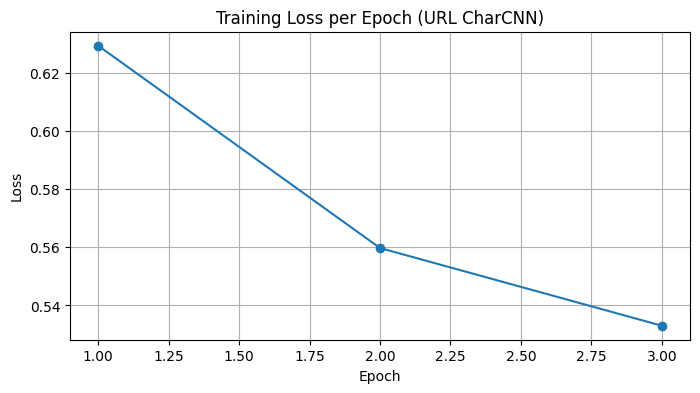

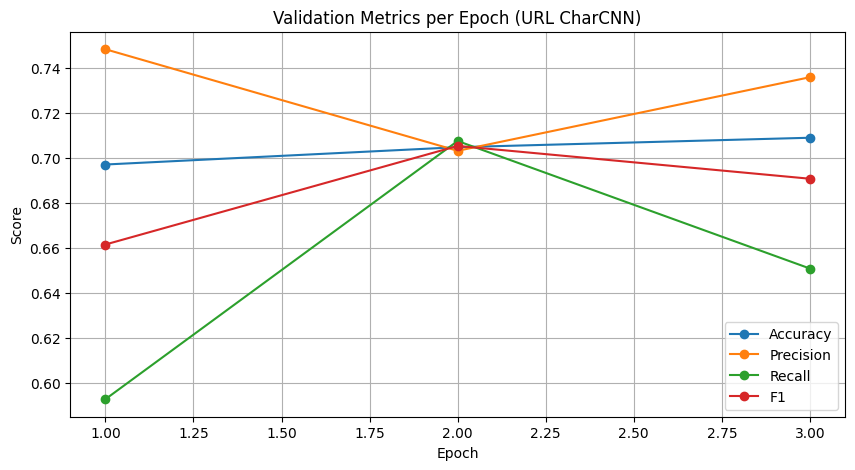

In [ ]:
hist_df = pd.DataFrame(train_history)
print("\n[INFO] Training history:")
print(hist_df)

plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_loss"], marker="o")
plt.title("Training Loss per Epoch (URL CharCNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for col, label in [
    ("val_accuracy", "Accuracy"),
    ("val_precision", "Precision"),
    ("val_recall", "Recall"),
    ("val_f1", "F1"),
]:
    if col in hist_df:
        plt.plot(hist_df["epoch"], hist_df[col], marker="o", label=label)

plt.title("Validation Metrics per Epoch (URL CharCNN)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# Final Confusion Matrix & Classification Report

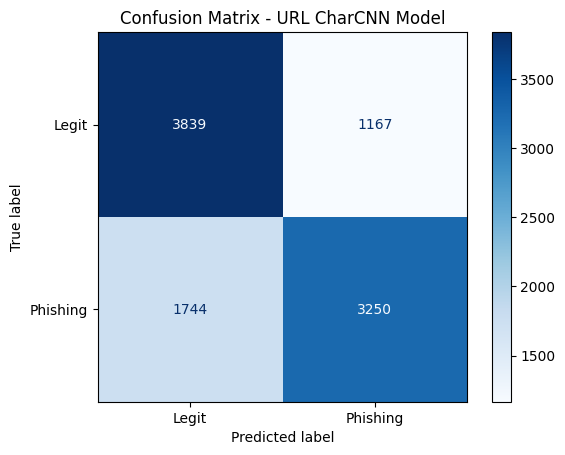


Classification Report (URL CharCNN):
              precision    recall  f1-score   support

       Legit       0.69      0.77      0.73      5006
    Phishing       0.74      0.65      0.69      4994

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



In [ ]:
final_metrics = evaluate(model, val_loader)
y_true = final_metrics["labels"]
y_pred = final_metrics["preds"]

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - URL CharCNN Model")
plt.show()

print("\nClassification Report (URL CharCNN):")
print(classification_report(y_true, y_pred, target_names=["Legit", "Phishing"]))

# Precision–Recall Curve

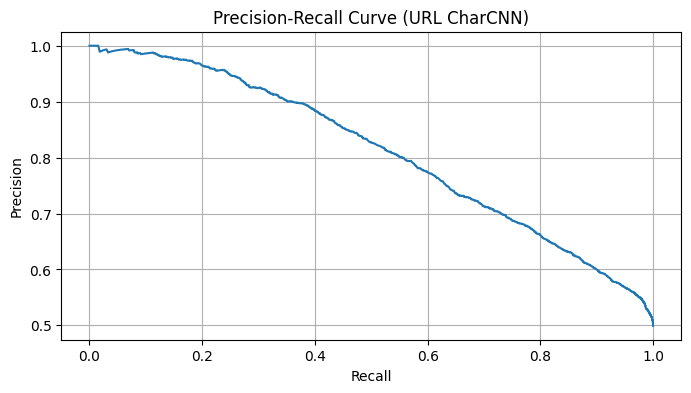

In [ ]:
y_probs = final_metrics["probs"]
prec, rec, thresh = precision_recall_curve(y_true, y_probs)

plt.figure(figsize=(8, 4))
plt.plot(rec, prec)
plt.title("Precision-Recall Curve (URL CharCNN)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


# Threshold Tuning Module

[INFO] Collected 10000 validation samples

=== Optimal Threshold Found ===
Best F1: 0.7243
Best Threshold: 0.3400


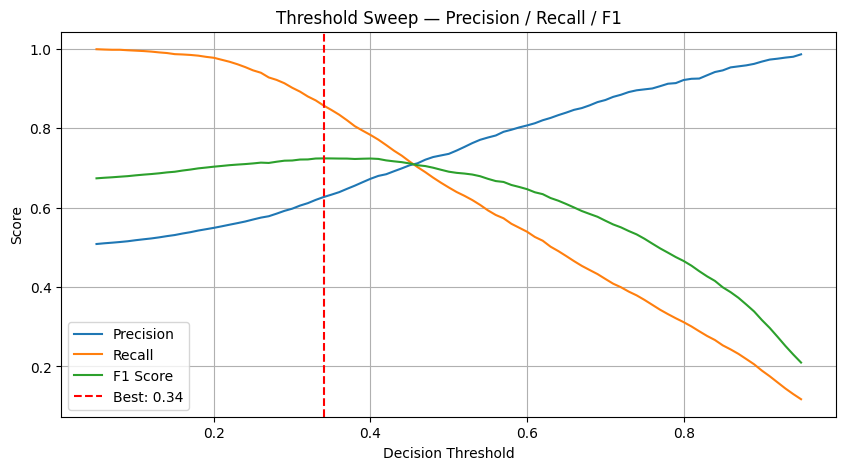

[OK] Saved best threshold to url_charcnn_only_stage3/best_threshold.json


In [ ]:
def collect_val_probs(model, val_loader, device):
    model.eval()
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels    = batch["labels"].cpu().numpy()

            logits = model(input_ids)
            probs  = torch.softmax(logits, dim=1)[:,1]   # phishing prob

            all_labels.extend(labels)
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)


# 1) Collect validation probabilities
y_true, y_prob = collect_val_probs(model, val_loader, device)

print(f"[INFO] Collected {len(y_true)} validation samples")


# 2) Sweep thresholds
thresholds = np.linspace(0.05, 0.95, 91)  # step = 0.01
results = []

best_f1 = 0
best_threshold = 0.5

for th in thresholds:
    preds = (y_prob >= th).astype(int)

    acc  = accuracy_score(y_true, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, preds, average="binary", zero_division=0
    )

    results.append([th, acc, prec, rec, f1])

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

th_df = pd.DataFrame(results, columns=["threshold", "accuracy", "precision", "recall", "f1"])

print("\n=== Optimal Threshold Found ===")
print(f"Best F1: {best_f1:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")


# 4) Plot curves
plt.figure(figsize=(10,5))
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["f1"], label="F1 Score")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best: {best_threshold:.2f}")
plt.title("Threshold Sweep — Precision / Recall / F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()


# 5) Save threshold to disk
THRESH_PATH = os.path.join(OUT_DIR, "best_threshold.json")
with open(THRESH_PATH, "w") as f:
    json.dump({"threshold": float(best_threshold)}, f)
print(f"[OK] Saved best threshold to {THRESH_PATH}")


# Inference Helpers

In [ ]:
# Helper: encode single URL
def encode_single_url(url: str):
    url_norm = normalize_url(url)
    ids = encode_url_text(url_norm, char2idx)
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device), url_norm


# Predict with threshold
def predict_url(url: str, threshold=None):
    model.eval()

    # load saved threshold if none provided
    if threshold is None:
        th_path = os.path.join(OUT_DIR, "best_threshold.json")
        if os.path.exists(th_path):
            threshold = json.load(open(th_path))["threshold"]
            print(f"Loaded threshold: {threshold}")
        else:
            threshold = 0.5

    x, url_norm = encode_single_url(url)

    with torch.no_grad(), autocast(device_type=device, enabled=True):
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pred = 1 if probs[1] >= threshold else 0

    return {
        "url": url,
        "normalized": url_norm,
        "prediction": "PHISHING" if pred else "LEGIT",
        "prob_legit": float(probs[0]),
        "prob_phishing": float(probs[1]),
        "threshold_used": threshold
    }


# Interactive mode
print("\n[INFO] CharCNN URL Predictor Ready (type b/break to exit)")
while True:
    url = input("Input URL: ")
    if url.lower() in ("b", "break", "exit", "quit", "q"):
        break

    res = predict_url(url)
    for k, v in res.items():
        print(f"{k}: {v}")
    print("-" * 50)


[INFO] CharCNN URL Predictor Ready (type b/break to exit)
Loaded threshold: 0.33999999999999997
url: google.com
normalized: google.com
prediction: LEGIT
prob_legit: 0.7026321291923523
prob_phishing: 0.2973679304122925
threshold_used: 0.33999999999999997
--------------------------------------------------
Loaded threshold: 0.33999999999999997
url: https://www.google.com/search?q=openai&client=%31%32%33&redirect=%2F%2E%2E%2F&sourceid=chrome&ie=UTF-8
normalized: google.com/search?q=openai&client=%31%32%33&redirect=%2f%2e%2e%2f&sourceid=chrome&ie=utf-8
prediction: LEGIT
prob_legit: 0.730289876461029
prob_phishing: 0.26971012353897095
threshold_used: 0.33999999999999997
--------------------------------------------------
Loaded threshold: 0.33999999999999997
url: https://example.com/security/update?next=%2F%2Faccounts.google.com.recovery.example.net
normalized: example.com/security/update?next=%2f%2faccounts.google.com.recovery.example.net
prediction: PHISHING
prob_legit: 0.641176700592041
p